In [1]:
import openeo

connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


In [ ]:
aoi = {
    "type": "Polygon",
   
    "coordinates": [
        [
            [
              112.1100469,
              -7.6193825
            ],
            [
              112.1674055997562,
              -7.6193825
            ],
            [
              112.1674055997562,
              -7.533958294404002
            ],
            [
              112.1100469,
              -7.533958294404002
            ],
            [
              112.1100469,
              -7.6193825
            ]
        ]
    ]
}
s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-09-01", "2026-09-01"],
    spatial_extent={
        "west": 112.1100469,
        "south": -7.6193825,
        "east": 112.1674055997562,
        "north": -7.533958294404002
    },
    # Disesuaikan dengan data yang dibutuhkan
    bands=["CO"],
)

# Agregasi harian agar tidak ada lebih dari satu data per hari
s5p_co_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Agregasi spasial untuk menghasilkan rata-rata time series per AOI
s5p_co_aoi = s5p_co_daily.aggregate_spatial(reducer="mean", geometries=aoi)

# Simpan hasil sebagai CSV
result = s5p_co_aoi.save_result(format="CSV")

# Jalankan job
job = result.create_job(title="s5p_co_timeseries")
job.start_and_wait()

# Download
job.get_results().download_files("output_co")

0:00:00 Job 'j-260911120906403ea18bd3f4872ba9bf': send 'start'
0:00:07 Job 'j-260911120906403ea18bd3f4872ba9bf': queued (progress 0%)
0:00:12 Job 'j-260911120906403ea18bd3f4872ba9bf': queued (progress 0%)
0:00:19 Job 'j-260911120906403ea18bd3f4872ba9bf': queued (progress 0%)
0:00:27 Job 'j-260911120906403ea18bd3f4872ba9bf': queued (progress 0%)
0:00:37 Job 'j-260911120906403ea18bd3f4872ba9bf': queued (progress 0%)
0:00:50 Job 'j-260911120906403ea18bd3f4872ba9bf': queued (progress 0%)
0:01:05 Job 'j-260911120906403ea18bd3f4872ba9bf': queued (progress 0%)
0:01:25 Job 'j-260911120906403ea18bd3f4872ba9bf': running (progress N/A)
0:01:49 Job 'j-260911120906403ea18bd3f4872ba9bf': running (progress N/A)
0:02:19 Job 'j-260911120906403ea18bd3f4872ba9bf': running (progress N/A)
0:02:57 Job 'j-260911120906403ea18bd3f4872ba9bf': running (progress N/A)
0:03:44 Job 'j-260911120906403ea18bd3f4872ba9bf': running (progress N/A)
0:04:42 Job 'j-260911120906403ea18bd3f4872ba9bf': finished (progress 100%)


[WindowsPath('output_co/timeseries.csv'),
 WindowsPath('output_co/job-results.json')]

In [9]:
import pandas as pd

# Baca hasil crawling CO dari folder output.
df_co = pd.read_csv("output_co/timeseries.csv", sep=",")
df_co = df_co[["date", "CO"]].copy()
df_co["date"] = pd.to_datetime(df_co["date"], errors="coerce")
df_co["CO"] = pd.to_numeric(df_co["CO"], errors="coerce")
df_co = df_co[
    (df_co["date"] >= "2025-08-31")
    & (df_co["date"] <= "2026-08-31")
].copy()
df_co["date"] = df_co["date"].dt.strftime("%Y-%m-%d")

df_co.to_csv("CO_Bandarkedungmulyo_timeseries.csv", index=False)
print("File berhasil dibuat: CO_Bandarkedungmulyo_timeseries.csv")
print("Ukuran data:", df_co.shape)
df_co.head()

File berhasil dibuat: CO_Bandarkedungmulyo_timeseries.csv
Ukuran data: (365, 2)


,date,CO
0,2025-10-11,0.029615
1,2025-10-12,0.028392
2,2025-10-14,0.035424
3,2025-10-09,0.040270
4,2025-10-13,0.027899


In [ ]:
aoi = {
    "type": "Polygon",
   
    "coordinates": [
        [
            [
              112.1100469,
              -7.6193825
            ],
            [
              112.1674055997562,
              -7.6193825
            ],
            [
              112.1674055997562,
              -7.533958294404002
            ],
            [
              112.1100469,
              -7.533958294404002
            ],
            [
              112.1100469,
              -7.6193825
            ]
        ]
    ]
}
s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-09-01", "2026-09-01"],
    spatial_extent={
        "west": 112.1100469,
        "south": -7.6193825,
        "east": 112.1674055997562,
        "north": -7.533958294404002
    },
    # Disesuaikan dengan data yang dibutuhkan
    bands=["NO2"],
)

# Agregasi harian agar tidak ada lebih dari satu data per hari
s5p_no2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Agregasi spasial untuk menghasilkan rata-rata time series per AOI
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

# Simpan hasil sebagai CSV
result = s5p_no2_aoi.save_result(format="CSV")

# Jalankan job
job = result.create_job(title="s5p_no2_timeseries")
job.start_and_wait()

# Download
job.get_results().download_files("output_no2")

0:00:00 Job 'j-2609111214264197bb881e78d8089a4d': send 'start'
0:00:05 Job 'j-2609111214264197bb881e78d8089a4d': queued (progress 0%)
0:00:11 Job 'j-2609111214264197bb881e78d8089a4d': queued (progress 0%)
0:00:18 Job 'j-2609111214264197bb881e78d8089a4d': queued (progress 0%)
0:00:26 Job 'j-2609111214264197bb881e78d8089a4d': queued (progress 0%)
0:00:36 Job 'j-2609111214264197bb881e78d8089a4d': queued (progress 0%)
0:00:48 Job 'j-2609111214264197bb881e78d8089a4d': queued (progress 0%)
0:01:04 Job 'j-2609111214264197bb881e78d8089a4d': queued (progress 0%)
0:01:23 Job 'j-2609111214264197bb881e78d8089a4d': running (progress N/A)
0:01:47 Job 'j-2609111214264197bb881e78d8089a4d': running (progress N/A)
0:02:18 Job 'j-2609111214264197bb881e78d8089a4d': running (progress N/A)
0:02:55 Job 'j-2609111214264197bb881e78d8089a4d': running (progress N/A)
0:03:42 Job 'j-2609111214264197bb881e78d8089a4d': running (progress N/A)
0:04:41 Job 'j-2609111214264197bb881e78d8089a4d': running (progress N/A)
0:

[WindowsPath('output_no2/timeseries.csv'),
 WindowsPath('output_no2/job-results.json')]

In [10]:
import pandas as pd

# Baca hasil crawling SO2 dari folder output.
df_so2 = pd.read_csv("output_so2/timeseries.csv", sep=",")
df_so2 = df_so2[["date", "SO2"]].copy()
df_so2["date"] = pd.to_datetime(df_so2["date"], errors="coerce")
df_so2["SO2"] = pd.to_numeric(df_so2["SO2"], errors="coerce")
df_so2 = df_so2[
    (df_so2["date"] >= "2025-08-31")
    & (df_so2["date"] <= "2026-08-31")
].copy()
df_so2["date"] = df_so2["date"].dt.strftime("%Y-%m-%d")

df_so2.to_csv("SO2_Bandarkedungmulyo_timeseries.csv", index=False)
print("File berhasil dibuat: SO2_Bandarkedungmulyo_timeseries.csv")
print("Ukuran data:", df_so2.shape)
df_so2.head()

File berhasil dibuat: SO2_Bandarkedungmulyo_timeseries.csv
Ukuran data: (365, 2)


,date,SO2
0,2025-11-30,NaN
1,2025-11-26,NaN
2,2025-11-25,NaN
3,2025-11-28,NaN
4,2025-11-29,NaN


In [ ]:
aoi = {
    "type": "Polygon",
   
    "coordinates": [
        [
            [
              112.1100469,
              -7.6193825
            ],
            [
              112.1674055997562,
              -7.6193825
            ],
            [
              112.1674055997562,
              -7.533958294404002
            ],
            [
              112.1100469,
              -7.533958294404002
            ],
            [
              112.1100469,
              -7.6193825
            ]
        ]
    ]
}
s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-09-01", "2026-09-01"],
    spatial_extent={
        "west": 112.1100469,
        "south": -7.6193825,
        "east": 112.1674055997562,
        "north": -7.533958294404002
    },
    # Disesuaikan dengan data yang dibutuhkan
    bands=["SO2"],
)

# Agregasi harian agar tidak ada lebih dari satu data per hari
s5p_so2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Agregasi spasial untuk menghasilkan rata-rata time series per AOI
s5p_so2_aoi = s5p_so2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

# Simpan hasil sebagai CSV
result = s5p_so2_aoi.save_result(format="CSV")

# Jalankan job
job = result.create_job(title="s5p_so2_timeseries")
job.start_and_wait()

# Download
job.get_results().download_files("output_so2")

0:00:00 Job 'j-2609111220184e5785b23790e0ed00df': send 'start'
0:00:04 Job 'j-2609111220184e5785b23790e0ed00df': created (progress 0%)
0:00:10 Job 'j-2609111220184e5785b23790e0ed00df': queued (progress 0%)
0:00:16 Job 'j-2609111220184e5785b23790e0ed00df': queued (progress 0%)
0:00:25 Job 'j-2609111220184e5785b23790e0ed00df': running (progress N/A)
0:00:35 Job 'j-2609111220184e5785b23790e0ed00df': running (progress N/A)
0:00:47 Job 'j-2609111220184e5785b23790e0ed00df': running (progress N/A)
0:01:03 Job 'j-2609111220184e5785b23790e0ed00df': running (progress N/A)
0:01:22 Job 'j-2609111220184e5785b23790e0ed00df': running (progress N/A)
0:01:46 Job 'j-2609111220184e5785b23790e0ed00df': running (progress N/A)
0:02:17 Job 'j-2609111220184e5785b23790e0ed00df': running (progress N/A)
0:02:54 Job 'j-2609111220184e5785b23790e0ed00df': running (progress N/A)
0:03:41 Job 'j-2609111220184e5785b23790e0ed00df': running (progress N/A)
0:04:40 Job 'j-2609111220184e5785b23790e0ed00df': running (progres

[WindowsPath('output_so2/timeseries.csv'),
 WindowsPath('output_so2/job-results.json')]

In [11]:
import pandas as pd

# Baca hasil crawling NO2 dari folder output.
df_no2 = pd.read_csv("output_no2/timeseries.csv", sep=",")
df_no2 = df_no2[["date", "NO2"]].copy()
df_no2["date"] = pd.to_datetime(df_no2["date"], errors="coerce")
df_no2["NO2"] = pd.to_numeric(df_no2["NO2"], errors="coerce")
df_no2 = df_no2[
    (df_no2["date"] >= "2025-08-31")
    & (df_no2["date"] <= "2026-08-31")
].copy()
df_no2["date"] = df_no2["date"].dt.strftime("%Y-%m-%d")

df_no2.to_csv("NO2_Bandarkedungmulyo_timeseries.csv", index=False)
print("File berhasil dibuat: NO2_Bandarkedungmulyo_timeseries.csv")
print("Ukuran data:", df_no2.shape)
df_no2.head()

File berhasil dibuat: NO2_Bandarkedungmulyo_timeseries.csv
Ukuran data: (365, 2)


,date,NO2
0,2026-02-14,NaN
1,2026-02-13,NaN
2,2026-02-16,NaN
3,2026-02-19,NaN
4,2026-02-18,NaN


In [ ]:
# Buat hasil NetCDF untuk SO2 Bandarkedungmulyo
s5p_so2_daily = s5post.aggregate_temporal_period(
    reducer="mean", period="day"
)
s5p_so2_aoi = s5p_so2_daily.aggregate_spatial(
    reducer="mean", geometries=aoi
)

result_so2 = s5p_so2_aoi.save_result(format="NetCDF")
job_so2 = result_so2.create_job(title="SO2 in Bandarkedungmulyo")
job_so2.start_and_wait()
job_so2.get_results().download_files(".")

0:00:00 Job 'j-2609071726394ddd8e9d60093c26dd70': send 'start'
0:00:06 Job 'j-2609071726394ddd8e9d60093c26dd70': queued (progress 0%)
0:00:12 Job 'j-2609071726394ddd8e9d60093c26dd70': queued (progress 0%)
0:00:18 Job 'j-2609071726394ddd8e9d60093c26dd70': queued (progress 0%)
0:00:26 Job 'j-2609071726394ddd8e9d60093c26dd70': queued (progress 0%)
0:00:37 Job 'j-2609071726394ddd8e9d60093c26dd70': queued (progress 0%)
0:00:49 Job 'j-2609071726394ddd8e9d60093c26dd70': queued (progress 0%)
0:01:05 Job 'j-2609071726394ddd8e9d60093c26dd70': running (progress N/A)
0:01:24 Job 'j-2609071726394ddd8e9d60093c26dd70': running (progress N/A)
0:01:48 Job 'j-2609071726394ddd8e9d60093c26dd70': running (progress N/A)
0:02:19 Job 'j-2609071726394ddd8e9d60093c26dd70': running (progress N/A)
0:02:57 Job 'j-2609071726394ddd8e9d60093c26dd70': running (progress N/A)
0:03:44 Job 'j-2609071726394ddd8e9d60093c26dd70': finished (progress 100%)


In [18]:
import pandas as pd

# Gunakan hasil NO2 yang sudah dibaca dari file crawling NO2.
# Jangan gunakan NO2DiBandarkedungmulyo.nc lama karena isinya ternyata SO2.
df_no2 = pd.read_csv("NO2_Bandarkedungmulyo_timeseries.csv")
df_no2["date"] = pd.to_datetime(df_no2["date"], errors="coerce")
df_no2["NO2"] = pd.to_numeric(df_no2["NO2"], errors="coerce")

print("Kolom yang digunakan:", list(df_no2.columns))
df_no2.head()

Kolom yang digunakan: ['date', 'NO2']


,date,NO2
0,2025-08-25,3.400000e+10
1,2025-08-26,5.560000e+10
2,2025-08-27,3.210000e+10
3,2025-08-28,2.380000e+11
4,2025-08-29,2.510000e+10


In [ ]:
import pandas as pd

# Gunakan data SO2 yang sudah diproses untuk Bandarkedungmulyo.
df_so2 = pd.read_csv("SO2_Bandarkedungmulyo_timeseries.csv")
df_so2.columns = ["date", "SO2"]
df_so2["date"] = pd.to_datetime(df_so2["date"], errors="coerce")
df_so2["SO2"] = pd.to_numeric(df_so2["SO2"], errors="coerce")
df_so2 = df_so2[
    (df_so2["date"] >= "2025-08-31")
    & (df_so2["date"] <= "2026-08-31")
].copy()
df_so2["date"] = df_so2["date"].dt.strftime("%Y-%m-%d")

df_so2.to_csv("SO2_Bandarkedungmulyo_timeseries.csv", index=False)
df_so2.head()

,date,SO2
0,2025-08-29,2.627389e+10
1,2025-08-30,1.803272e-04
2,2025-08-31,-1.052493e-04
3,2025-09-01,4.357044e-04
4,2025-09-02,3.369446e+10


In [12]:
import pandas as pd

# Gabungkan tiga indikator Bandarkedungmulyo berdasarkan tanggal.
df_co = pd.read_csv("CO_Bandarkedungmulyo_timeseries.csv")
df_no2 = pd.read_csv("NO2_Bandarkedungmulyo_timeseries.csv")
df_so2 = pd.read_csv("SO2_Bandarkedungmulyo_timeseries.csv")

polutan_bandarkedungmulyo = df_co.merge(df_no2, on="date", how="inner")
polutan_bandarkedungmulyo = polutan_bandarkedungmulyo.merge(
    df_so2, on="date", how="inner"
)

polutan_bandarkedungmulyo.to_csv(
    "Polutan_Bandarkedungmulyo.csv", index=False
)
polutan_bandarkedungmulyo.head()

,date,CO,NO2,SO2
0,2025-10-11,0.029615,0.000039,-0.000219
1,2025-10-12,0.028392,0.000035,0.000113
2,2025-10-14,0.035424,0.000054,0.000127
3,2025-10-09,0.040270,0.000030,0.000143
4,2025-10-13,0.027899,0.000038,-0.000183


In [3]:
import pandas as pd

# Gunakan data NO2 yang sudah diproses untuk Bandarkedungmulyo.
df_no2 = pd.read_csv("NO2_Bandarkedungmulyo_timeseries.csv")
df_no2.columns = ["date", "NO2"]
df_no2["date"] = pd.to_datetime(df_no2["date"], errors="coerce")
df_no2["NO2"] = pd.to_numeric(df_no2["NO2"], errors="coerce")
df_no2 = df_no2[
    (df_no2["date"] >= "2025-08-31")
    & (df_no2["date"] <= "2026-08-31")
].copy()
df_no2["date"] = df_no2["date"].dt.strftime("%Y-%m-%d")

df_no2.to_csv("NO2_Bandarkedungmulyo_timeseries.csv", index=False)
df_no2.head()

,date,NO2
0,2026-02-14,NaN
1,2026-02-13,NaN
2,2026-02-16,NaN
3,2026-02-19,NaN
4,2026-02-18,NaN


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("NO2_Bandarkedungmulyo_timeseries.csv")
df['date'] = pd.to_datetime(df['date'])

# Hitung IQR (Interquartile Range)
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'NO2']].head())

Jumlah Outlier (IQR): 2
          date       NO2
218 2025-10-02  0.000072
354 2025-10-15  0.000069


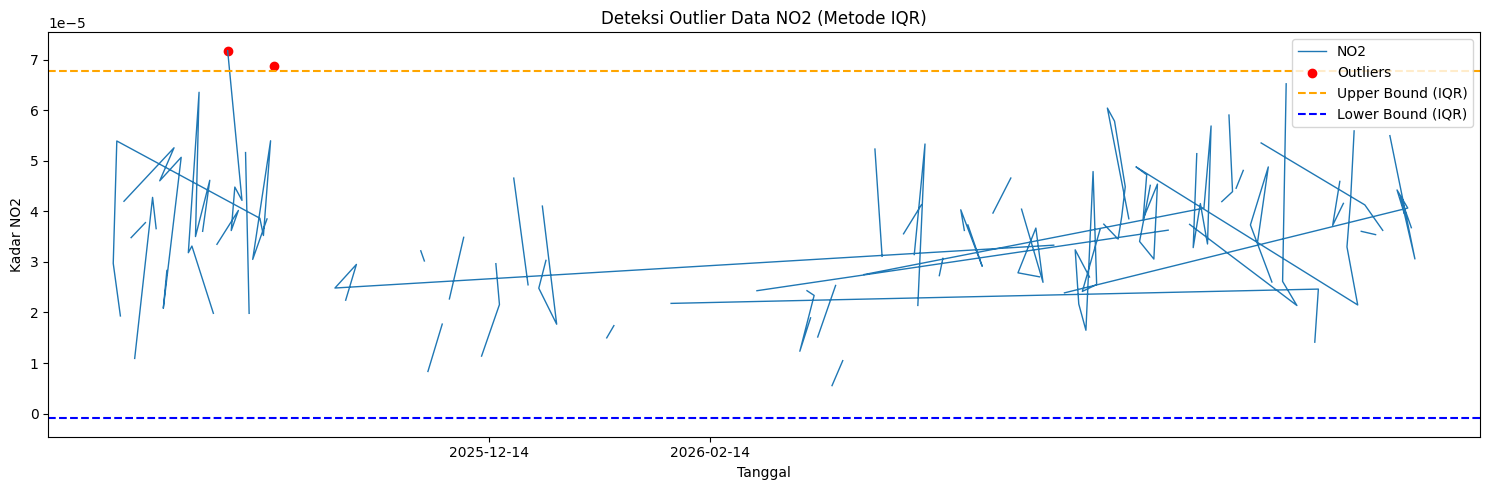

In [27]:
# === Visualisasi ===
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)

# Titik Outlier
plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'],
            color='red', marker='o', label="Outliers")

# Garis batas atas & bawah
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue', linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

In [28]:
# Tandai outlier menjadi NaN
df['NO2_cleaned'] = df['NO2'].mask((df['NO2'] < lower_bound) | (df['NO2'] > upper_bound))

print("Jumlah nilai yang dinyatakan sebagai outlier:", df['NO2_cleaned'].isna().sum())
df = df.sort_values('date')
# Interpolasi linear untuk mengisi kembali nilai outlier
df['NO2_filled'] = df['NO2_cleaned'].interpolate(method='linear')

# Jika masih tersisa NaN di ujung data, isi dengan forward/backward fill
df['NO2_filled'] = df['NO2_filled'].bfill().ffill()

print("Jumlah missing setelah interpolasi:", df['NO2_filled'].isna().sum())

Jumlah nilai yang dinyatakan sebagai outlier: 185
Jumlah missing setelah interpolasi: 0


In [30]:
from pathlib import Path

# Simpan data NO2 hasil penghapusan outlier dan pengisian missing value.
df_no2_hasil = df[["date", "NO2_filled"]].copy()
df_no2_hasil = df_no2_hasil.rename(columns={"NO2_filled": "NO2"})
df_no2_hasil = df_no2_hasil.sort_values("date").reset_index(drop=True)

output_hasil = Path("NO2_Bandarkedungmulyo_timeseries_final.csv")
nomor_file = 1
while output_hasil.exists():
    output_hasil = Path(
        f"NO2_Bandarkedungmulyo_timeseries_final_{nomor_file}.csv"
    )
    nomor_file += 1

df_no2_hasil.to_csv(output_hasil, index=False)
print("File data berhasil disimpan:", output_hasil)
print("Jumlah baris:", len(df_no2_hasil))
print("Jumlah missing NO2:", df_no2_hasil["NO2"].isna().sum())
df_no2_hasil.head()

File data berhasil disimpan: NO2_Bandarkedungmulyo_timeseries_final.csv
Jumlah baris: 365
Jumlah missing NO2: 0


,date,NO2
0,2025-08-31,0.000030
1,2025-09-01,0.000054
2,2025-09-02,0.000019
3,2025-09-03,0.000042
4,2025-09-04,0.000038


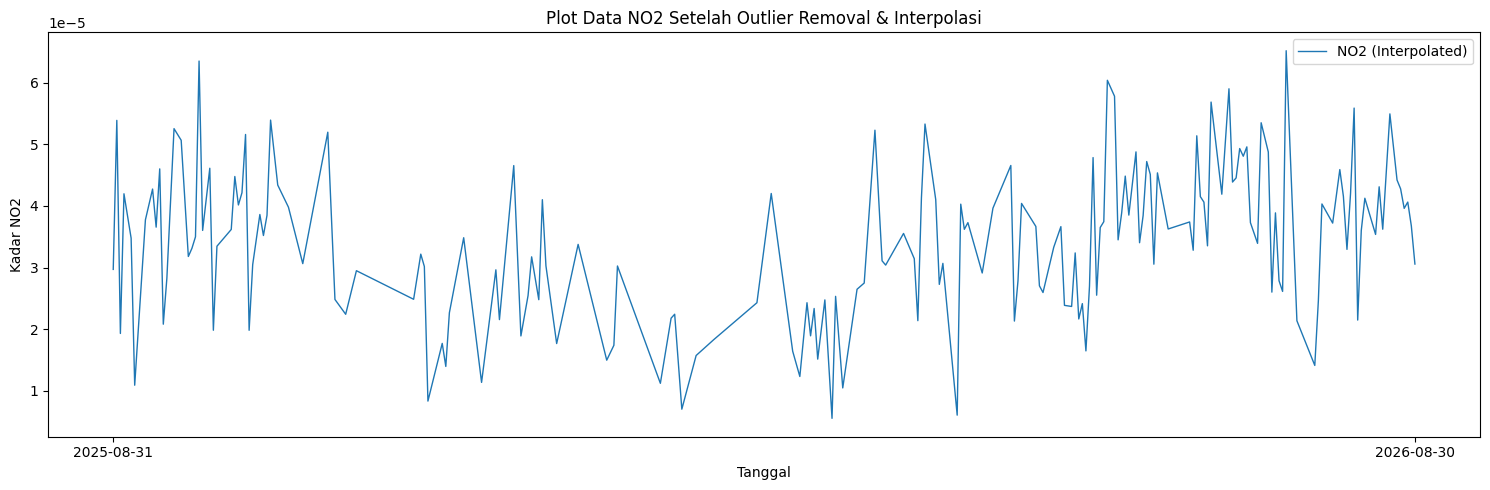

In [29]:
plt.figure(figsize=(15,5))
# Plot data hasil interpolasi
plt.plot(df['date'], df['NO2_filled'], label="NO2 (Interpolated)", linewidth=1)
# Tampilkan hanya tanggal awal dan akhir di sumbu X
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.title("Plot Data NO2 Setelah Outlier Removal & Interpolasi")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()


In [33]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat dan bersihkan data ----------
df = pd.read_csv('NO2_Bandarkedungmulyo_timeseries_final.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_pollutant = 'NO2'

# --- FIX: paksa kolom target jadi numerik, nilai yang gagal dikonversi -> NaN ---
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

n_missing_before = df[target_pollutant].isna().sum()
print(f"Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: {n_missing_before}")

Q1 = df[target_pollutant].quantile(0.25)
Q3 = df[target_pollutant].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df.loc[(df[target_pollutant] < lower_bound) | (df[target_pollutant] > upper_bound), target_pollutant] = np.nan

df_clean = df.set_index('date').interpolate(method='time').ffill().bfill()

fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# ---------- 2. Daftar PERSIS fitur yang diminta ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang dihasilkan untuk {target_pollutant}: {extracted_features_final.shape[1]}")
extracted_features_final.to_csv(f'{target_pollutant}_Bandarkedungmulyo_TSFEL.csv', index=False)

Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: 0
Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang dihasilkan untuk NO2: 68


In [34]:
import pandas as pd

# ---------- 1. Muat hasil ekstraksi TSFEL ----------
df_features = pd.read_csv('NO2_Bandarkedungmulyo_TSFEL.csv')

# ---------- 2. Mapping resmi fitur -> domain (sesuai features.json TSFEL) ----------
FEATURE_DOMAIN_MAP = {
    # Statistical (21)
    "abs_energy": "statistical", "average_power": "statistical", "calc_max": "statistical",
    "calc_mean": "statistical", "calc_median": "statistical", "calc_min": "statistical",
    "calc_std": "statistical", "calc_var": "statistical", "ecdf": "statistical",
    "ecdf_percentile": "statistical", "ecdf_percentile_count": "statistical",
    "ecdf_slope": "statistical", "entropy": "statistical", "hist_mode": "statistical",
    "interq_range": "statistical", "kurtosis": "statistical", "mean_abs_deviation": "statistical",
    "median_abs_deviation": "statistical", "pk_pk_distance": "statistical", "rms": "statistical",
    "skewness": "statistical",

    # Temporal (15)
    "auc": "temporal", "autocorr": "temporal", "calc_centroid": "temporal",
    "distance": "temporal", "lempel_ziv": "temporal", "mean_abs_diff": "temporal",
    "mean_diff": "temporal", "median_abs_diff": "temporal", "median_diff": "temporal",
    "negative_turning": "temporal", "neighbourhood_peaks": "temporal",
    "positive_turning": "temporal", "slope": "temporal", "sum_abs_diff": "temporal",
    "zero_cross": "temporal",

    # Spectral (26)
    "fundamental_frequency": "spectral", "human_range_energy": "spectral", "lpcc": "spectral",
    "max_frequency": "spectral", "max_power_spectrum": "spectral", "median_frequency": "spectral",
    "mfcc": "spectral", "power_bandwidth": "spectral", "spectral_centroid": "spectral",
    "spectral_decrease": "spectral", "spectral_distance": "spectral", "spectral_entropy": "spectral",
    "spectral_kurtosis": "spectral", "spectral_positive_turning": "spectral",
    "spectral_roll_off": "spectral", "spectral_roll_on": "spectral", "spectral_skewness": "spectral",
    "spectral_slope": "spectral", "spectral_spread": "spectral", "spectral_variation": "spectral",
    "spectrogram_mean_coeff": "spectral", "wavelet_abs_mean": "spectral", "wavelet_energy": "spectral",
    "wavelet_entropy": "spectral", "wavelet_std": "spectral", "wavelet_var": "spectral",

    # Fractal (6) - domain terpisah di TSFEL
    "dfa": "fractal", "higuchi_fractal_dimension": "fractal", "hurst_exponent": "fractal",
    "maximum_fractal_length": "fractal", "mse": "fractal", "petrosian_fractal_dimension": "fractal",
}

# ---------- 3. Kelompokkan kolom sesuai domain ----------
domain_columns = {"statistical": [], "temporal": [], "spectral": [], "fractal": [], "unknown": []}
for col in df_features.columns:
    domain = FEATURE_DOMAIN_MAP.get(col, "unknown")
    domain_columns[domain].append(col)

for domain, cols in domain_columns.items():
    print(f"{domain.upper()} ({len(cols)}): {cols}")

# ---------- 4. (Opsional) Pisah jadi DataFrame terpisah per domain ----------
df_statistical = df_features[domain_columns["statistical"]]
df_temporal = df_features[domain_columns["temporal"]]
df_spectral = df_features[domain_columns["spectral"]]
df_fractal = df_features[domain_columns["fractal"]]

# ---------- 5. (Opsional) Simpan masing-masing sebagai CSV terpisah ----------
df_statistical.to_csv('NO2_fitur_statistical.csv', index=False)
df_temporal.to_csv('NO2_fitur_temporal.csv', index=False)
df_spectral.to_csv('NO2_fitur_spectral.csv', index=False)
df_fractal.to_csv('NO2_fitur_fractal.csv', index=False)

STATISTICAL (21): ['abs_energy', 'average_power', 'calc_max', 'calc_mean', 'calc_median', 'calc_min', 'calc_std', 'calc_var', 'ecdf', 'ecdf_percentile', 'ecdf_percentile_count', 'ecdf_slope', 'entropy', 'hist_mode', 'interq_range', 'kurtosis', 'mean_abs_deviation', 'median_abs_deviation', 'pk_pk_distance', 'rms', 'skewness']
TEMPORAL (15): ['auc', 'autocorr', 'calc_centroid', 'distance', 'lempel_ziv', 'mean_abs_diff', 'mean_diff', 'median_abs_diff', 'median_diff', 'negative_turning', 'neighbourhood_peaks', 'positive_turning', 'slope', 'sum_abs_diff', 'zero_cross']
SPECTRAL (26): ['fundamental_frequency', 'human_range_energy', 'lpcc', 'max_frequency', 'max_power_spectrum', 'median_frequency', 'mfcc', 'power_bandwidth', 'spectral_centroid', 'spectral_decrease', 'spectral_distance', 'spectral_entropy', 'spectral_kurtosis', 'spectral_positive_turning', 'spectral_roll_off', 'spectral_roll_on', 'spectral_skewness', 'spectral_slope', 'spectral_spread', 'spectral_variation', 'spectrogram_mean_